In [1]:
import matplotlib.pyplot as plt
from data import sample_checkerboard, sample_swiss_roll
from flax import nnx
import numpy as np
from model import ToyModel
import optax


nnx_rngs = nnx.Rngs(0, params=1)

## Visualize the Drifting Field

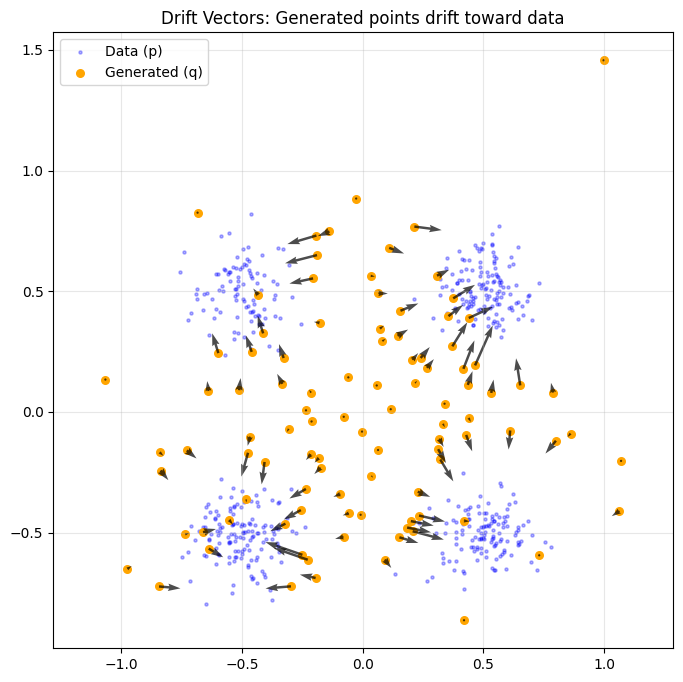

In [ ]:
from loss import compute_drift_field
import jax.numpy as jnp

np_rng = np.random.default_rng(seed=42)

sample_gen = np_rng.normal(size=(100, 2)) * 0.5
centers = np.array([[-0.5, -0.5], [-0.5, 0.5], [0.5, -0.5], [0.5, 0.5]])
idx = np_rng.integers(0, 4, 500)
pos = centers[idx] + np_rng.normal(size=(500, 2)) * 0.1

drift_field = compute_drift_field(sample_gen, pos, sample_gen, temp=0.05)

plt.figure(figsize=(8, 8))
plt.scatter(pos[:, 0], pos[:, 1], s=5, alpha=0.3, c='blue', label='Data (p)')
plt.scatter(sample_gen[:, 0], sample_gen[:, 1], s=30, c='orange', label='Generated (q)')
plt.quiver(sample_gen[:, 0], sample_gen[:, 1], drift_field[:, 0], drift_field[:, 1],
           scale=3, color='black', alpha=0.7, width=0.004)
plt.legend()
plt.title('Drift Vectors: Generated points drift toward data')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

## Checkerboard

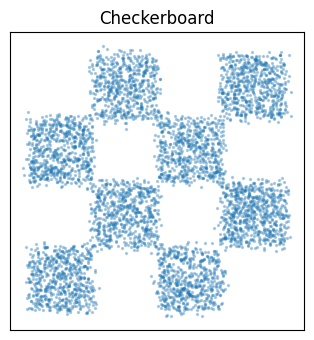

In [3]:
fig, ax = plt.subplots(figsize=(4, 3.5))

name, sampler = "Checkerboard", sample_checkerboard
pts = np.array(sampler(5000, 0.05, nnx_rngs)).T

ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(name)

plt.tight_layout()
plt.show()

  0%|          | 0/2500 [00:00<?, ?it/s]

Loss at step 1: 2.75e-05


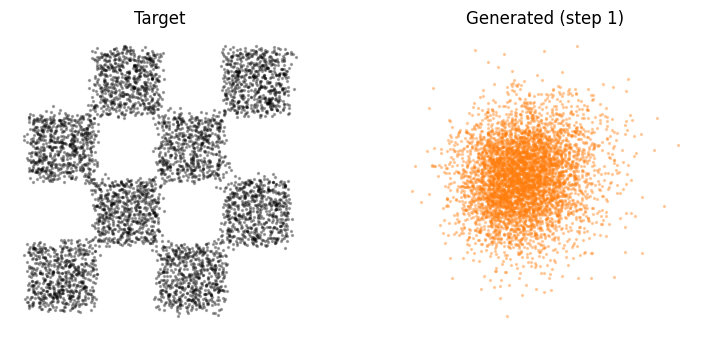

 20%|█▉        | 496/2500 [00:09<00:19, 104.43it/s, loss=3.19e-04]

Loss at step 500: 3.08e-04


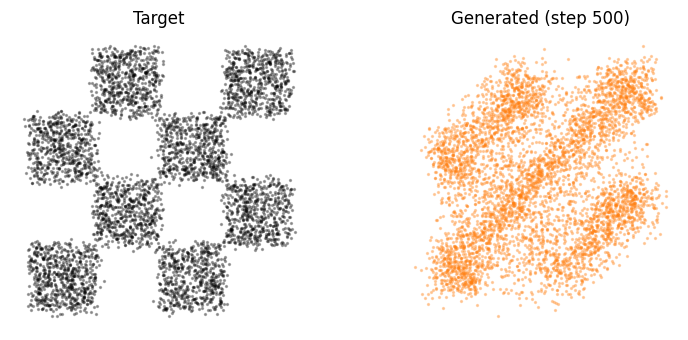

 40%|███▉      | 991/2500 [00:14<00:14, 105.01it/s, loss=2.95e-04]

Loss at step 1000: 2.79e-04


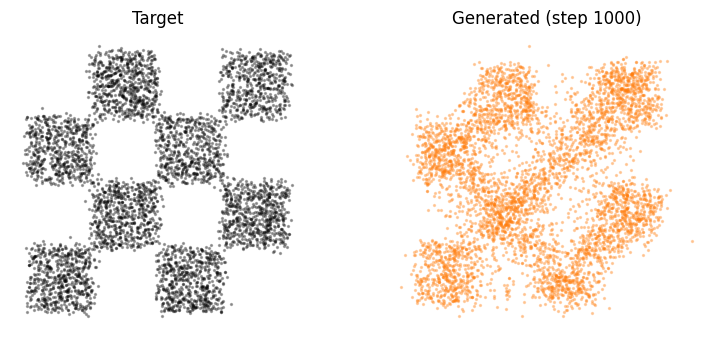

 60%|█████▉    | 1497/2500 [00:19<00:09, 107.25it/s, loss=2.35e-04]

Loss at step 1500: 2.53e-04


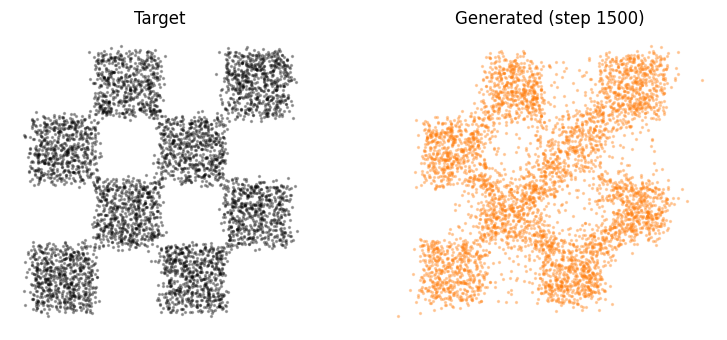

 80%|███████▉  | 1992/2500 [00:23<00:04, 107.53it/s, loss=1.92e-04]

Loss at step 2000: 2.50e-04


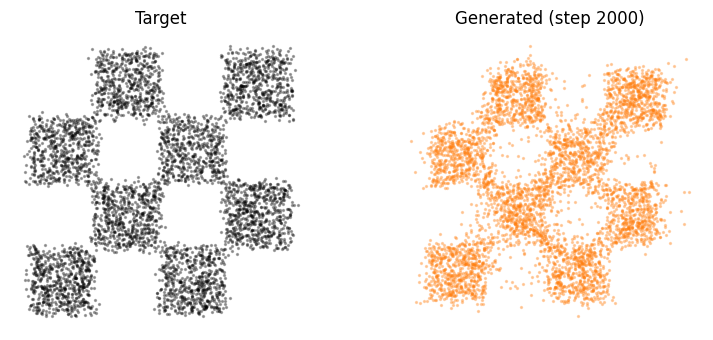

100%|█████████▉| 2498/2500 [00:28<00:00, 104.38it/s, loss=1.89e-04]

Loss at step 2500: 2.12e-04


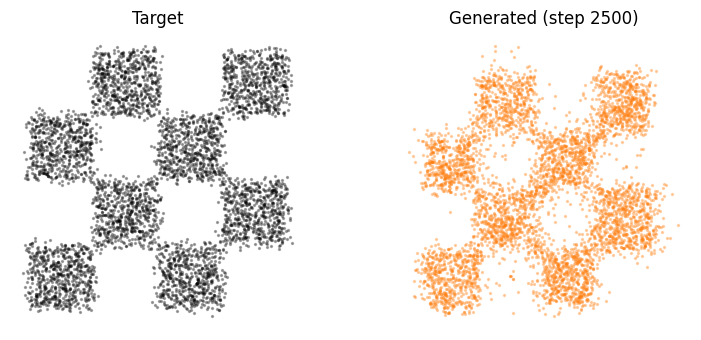

100%|██████████| 2500/2500 [00:29<00:00, 85.88it/s, loss=2.12e-04] 


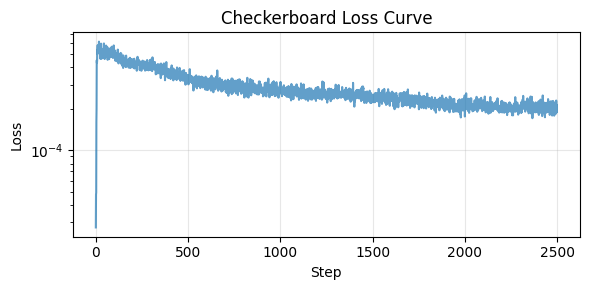

In [2]:
from tqdm import tqdm
import jax.random as jr
from loss import train_step

num_steps = 2500
data_batch_size = 2048
gen_batch_size = 2048
noise_dim = 32
hidden_dim = 256
out_dim = 2

model = ToyModel(noise_dim, hidden_dim, out_dim, rngs=nnx_rngs)
tx = optax.adam(learning_rate=1e-3)

optimizer = nnx.Optimizer(model, tx, wrt=nnx.Param)

pbar = tqdm(range(1, num_steps + 1))
loss_history = []
for step in pbar:
    datasample_bd = sample_checkerboard(data_batch_size, 0.05, nnx_rngs).T
    z_bd = jr.normal(nnx_rngs(), shape=(gen_batch_size, noise_dim))
    loss = train_step(model, optimizer, z_bd, datasample_bd)
    loss_history.append(loss)

    if step == 1 or step % 500 == 0:
        print(f"Loss at step {step}: {loss:.2e}")

        model.eval()
        zplot = jr.normal(nnx_rngs(), shape=(5000, noise_dim))
        vis = np.array(model(zplot))
        gt = sample_checkerboard(5000, 0.05, nnx_rngs).T
                
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
        ax1.scatter(gt[:, 0], gt[:, 1], s=2, alpha=0.3, c='black')
        ax1.set_title('Target'); ax1.set_aspect('equal'); ax1.axis('off')
        ax2.scatter(vis[:, 0], vis[:, 1], s=2, alpha=0.3, c='tab:orange')
        ax2.set_title(f'Generated (step {step})'); ax2.set_aspect('equal'); ax2.axis('off')
        plt.tight_layout(); plt.show()

        model.train()

    pbar.set_postfix(loss=f"{loss:.2e}")

plt.figure(figsize=(6, 3))
plt.plot(loss_history, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Checkerboard Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

## Spiral

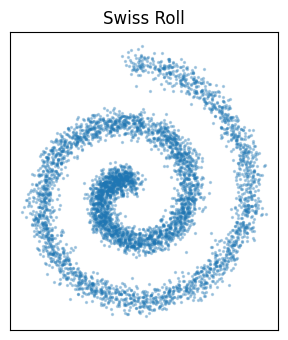

In [2]:
fig, ax = plt.subplots(figsize=(4, 3.5))

name, sampler = "Swiss Roll", sample_swiss_roll
pts = np.array(sampler(5000, 0.05, nnx_rngs)).T

ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3)
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(name)

plt.tight_layout()

  0%|          | 0/2500 [00:00<?, ?it/s]

Loss at step 1: 6.01e-04


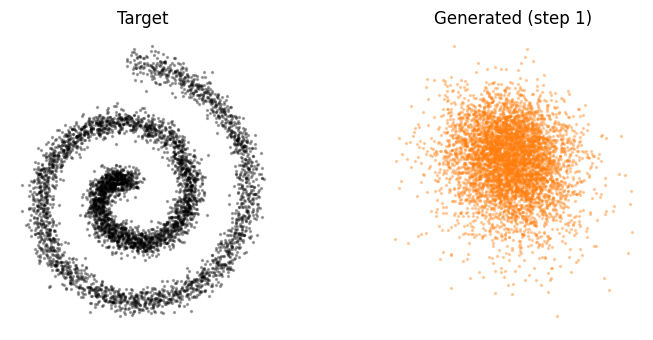

 20%|█▉        | 497/2500 [00:06<00:12, 157.96it/s, loss=4.11e-04]

Loss at step 500: 4.53e-04


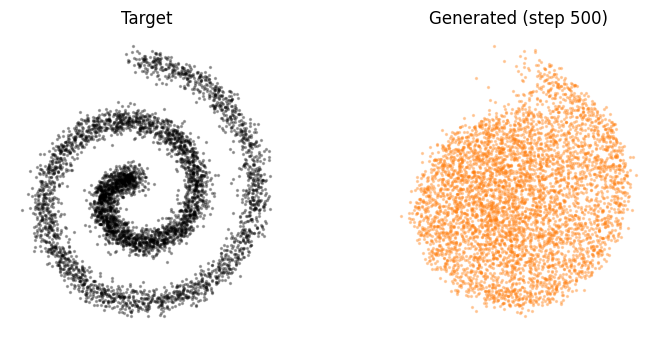

 40%|███▉      | 993/2500 [00:09<00:09, 159.23it/s, loss=6.56e-05]

Loss at step 1000: 9.32e-05


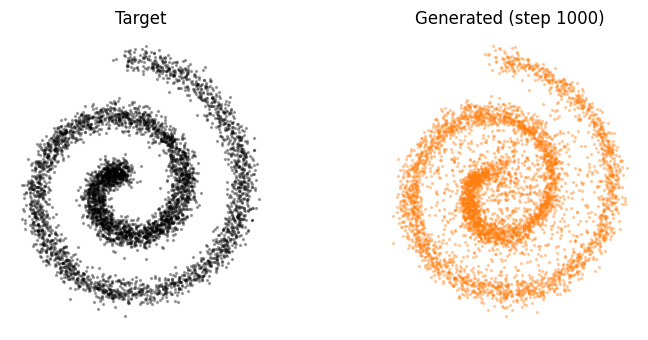

 60%|█████▉    | 1489/2500 [00:12<00:06, 159.09it/s, loss=4.72e-05]

Loss at step 1500: 3.52e-05


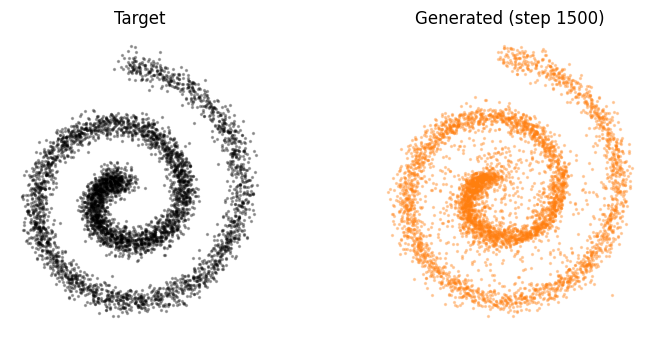

 79%|███████▉  | 1985/2500 [00:16<00:03, 157.30it/s, loss=4.99e-05]

Loss at step 2000: 4.35e-05


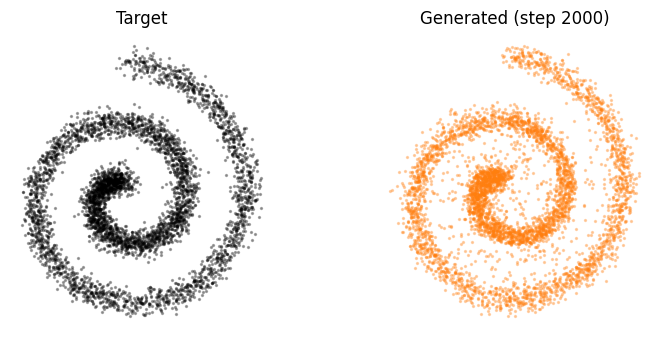

100%|█████████▉| 2497/2500 [00:19<00:00, 157.28it/s, loss=3.44e-05]

Loss at step 2500: 3.32e-05


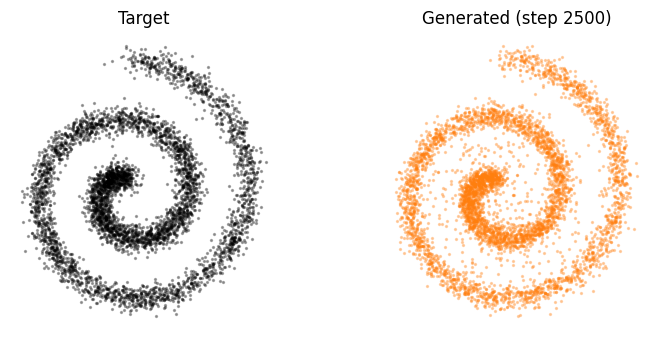

100%|██████████| 2500/2500 [00:19<00:00, 126.15it/s, loss=3.32e-05]


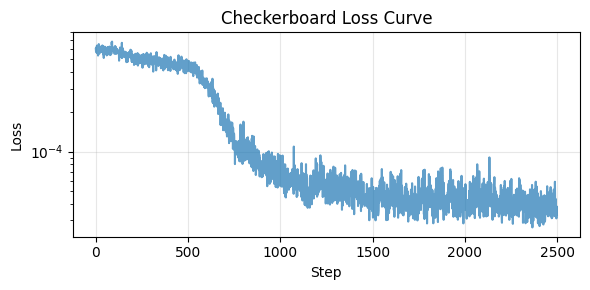

In [3]:
from tqdm import tqdm
import jax.random as jr
from loss import train_step

num_steps = 2500
data_batch_size = 2048
gen_batch_size = 2048
noise_dim = 32
hidden_dim = 256
out_dim = 2

model = ToyModel(noise_dim, hidden_dim, out_dim, rngs=nnx_rngs)
tx = optax.adam(learning_rate=1e-3)

optimizer = nnx.Optimizer(model, tx, wrt=nnx.Param)

pbar = tqdm(range(1, num_steps + 1))
loss_history = []
for step in pbar:
    datasample_bd = sample_swiss_roll(data_batch_size, 0.05, nnx_rngs).T
    z_bd = jr.normal(nnx_rngs(), shape=(gen_batch_size, noise_dim))
    loss = train_step(model, optimizer, z_bd, datasample_bd)
    loss_history.append(loss)

    if step == 1 or step % 500 == 0:
        print(f"Loss at step {step}: {loss:.2e}")

        model.eval()
        zplot = jr.normal(nnx_rngs(), shape=(5000, noise_dim))
        vis = np.array(model(zplot))
        gt = sample_swiss_roll(5000, 0.05, nnx_rngs).T
                
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.5))
        ax1.scatter(gt[:, 0], gt[:, 1], s=2, alpha=0.3, c='black')
        ax1.set_title('Target'); ax1.set_aspect('equal'); ax1.axis('off')
        ax2.scatter(vis[:, 0], vis[:, 1], s=2, alpha=0.3, c='tab:orange')
        ax2.set_title(f'Generated (step {step})'); ax2.set_aspect('equal'); ax2.axis('off')
        plt.tight_layout(); plt.show()

        model.train()

    pbar.set_postfix(loss=f"{loss:.2e}")

plt.figure(figsize=(6, 3))
plt.plot(loss_history, alpha=0.7)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Checkerboard Loss Curve')
plt.yscale('log'); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()